# Lab 02 — Open the box

Week 2 · AI course · Narxoz University · about 50 minutes · **no API key**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/unreal-kz/lab-02-AI-course/blob/main/lab02_inside_the_model.ipynb)

Lecture 3 told you what happens inside a language model. Today you check it, on a real model:
GPT-2 small, 124 million parameters, released in 2019. It runs on the free CPU that Colab gives you.
Three claims from the lecture get tested:

1. The output is not a word. It is a list of 50,257 probabilities.
2. Temperature reshapes that list. It cannot change which token is first. Top-p is a different operation.
3. Attention is a table of weights, and every row of it sums to one.

**The rule of this lab, inherited from Lab 01: write your prediction down *before* you run the cell.**
A prediction you did not write down is a prediction you will not remember getting wrong.

**Right now, run the next cell only** (click it, press Shift+Enter). It downloads the model while the
lecture continues. Do **not** use *Run all*: it would show you every answer before you have predicted it.
If a warning about `HF_TOKEN` appears, ignore it — the model is public.

Your answers go in the cells marked ✏️. Double-click a cell to edit it, Shift+Enter to save it.

In [1]:
import importlib.util
import subprocess
import sys

# Colab normally has all three already; this installs whatever is missing.
for pkg in ("torch", "transformers", "matplotlib"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import math

import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "openai-community/gpt2"

tok = AutoTokenizer.from_pretrained(MODEL)
# attn_implementation="eager" is required for Part 2: the default "sdpa" kernel never
# returns attention weights, so output_attentions=True would give you nothing.
model = AutoModelForCausalLM.from_pretrained(MODEL, attn_implementation="eager")
model.eval()

cfg = model.config
print(f"torch {torch.__version__} | transformers {transformers.__version__}")
print(f"parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"vocabulary      : {cfg.vocab_size:,} tokens")
print(f"layers x heads  : {cfg.n_layer} x {cfg.n_head}")
print(f"embedding table : {tuple(model.transformer.wte.weight.shape)}  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)")

C:\Users\dosba\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8400.07it/s]

torch 2.5.1+cu121 | transformers 5.12.1
parameters      : 124,439,808
vocabulary      : 50,257 tokens
layers x heads  : 12 x 12
embedding table : (50257, 768)  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)


## Part 0 — a token is not a word (4 min)

Lecture 3 measured six tokenizers. GPT-2's is the seventh, and the smallest: 50,257 entries, against
100,277 (cl100k), 128,000 (Llama 3) and 200,019 (o200k).

**✏️ Predict first.** The Kazakh word `бөлімшеңізде` took 12 tokens on cl100k and 7 on o200k.
How many will it take on GPT-2: more than 12, fewer, or the same? Write your number here:

> **Prediction:** more than 12 — about 15, because GPT-2's table is the smallest and trained mostly on English.
>
> **Measured:** 19 tokens (every Cyrillic letter is split into 1–2 byte tokens). `bank` = 1 token, `банк` = 5 tokens.

In [2]:
def show_tokens(text: str) -> None:
    ids = tok.encode(text)
    print(f"{text!r}: {len(ids)} tokens")
    print("  ids   :", ids)
    print("  pieces:", tok.convert_ids_to_tokens(ids))


for word in ["restore", "bank", "банк", "бөлімшеңізде"]:
    show_tokens(word)

'restore': 2 tokens
  ids   : [2118, 382]
  pieces: ['rest', 'ore']
'bank': 1 tokens
  ids   : [17796]
  pieces: ['bank']
'банк': 5 tokens
  ids   : [140, 109, 16142, 22177, 31583]
  pieces: ['Ð', '±', 'Ð°', 'Ð½', 'Ðº']
'бөлімшеңізде': 19 tokens
  ids   : [140, 109, 143, 102, 30143, 141, 244, 43108, 141, 230, 16843, 142, 96, 141, 244, 140, 115, 43666, 16843]
  pieces: ['Ð', '±', 'Ó', '©', 'Ð»', 'Ñ', 'ĸ', 'Ð¼', 'Ñ', 'Ī', 'Ðµ', 'Ò', '£', 'Ñ', 'ĸ', 'Ð', '·', 'Ð´', 'Ðµ']


`Ġ` in a piece means "this token starts with a space". The odd letters (`Ð`, `±` …) are single **bytes**
of a Cyrillic letter, printed as if they were characters — the same thing lecture slide 5 showed for `ө`.

**✏️ Your answer.** In the lecture's board derivation, three merges turned `банк` into one token.
GPT-2 needed several tokens for it. Using what slide 6 taught about where merges come from, why?

> **Answer:** Merges are learned from the training data: a pair gets merged only if it is frequent there. GPT-2 was trained almost only on English web text, so Cyrillic byte pairs were rarely seen and never merged into `банк` — it stays as bytes (`Ð` `±` …), 5 tokens instead of 1.

## Part 1 — the output is 50,257 numbers (10 min)

Slide 14: the model does not output a word. It outputs one score (a *logit*) for every token in its
vocabulary, and softmax turns the scores into probabilities.

**✏️ Predict first.** For the prompt

`The capital of Kazakhstan is Astana. The capital of France is`

what is GPT-2's most likely next token, and roughly what probability does it get? And do the ten
most likely tokens together hold more than 90% of all the probability, or less?

> **Prediction:** ` Paris`, about 40%; the top ten hold more than 90%.
>
> **Measured:** #1 is ` Ast` (22.87%), ` Paris` is second (22.08%). The top ten hold only 64.0% — the other 50,247 tokens share 36%. Both parts of my prediction were wrong.

In [3]:
@torch.no_grad()
def next_token_logits(prompt: str) -> torch.Tensor:
    """Scores for every token in the vocabulary as the continuation of `prompt`."""
    enc = tok(prompt, return_tensors="pt")
    return model(**enc).logits[0, -1]  # shape: (50257,)


def show_next_token(prompt: str, k: int = 10, T: float = 1.0) -> None:
    logits = next_token_logits(prompt)
    probs = torch.softmax(logits / T, dim=-1)
    top = torch.topk(probs, k)
    held = top.values.sum().item()
    print(f"prompt: {prompt!r}   T={T}")
    print(f"logits shape: {tuple(logits.shape)}   probabilities sum to {probs.sum().item():.4f}")
    for p, i in zip(top.values, top.indices):
        print(f"  {p.item():6.2%}   id {i.item():>6}   {tok.decode([i.item()])!r}")
    print(f"  top-{k} hold {held:.1%}; the other {probs.numel() - k:,} tokens share {1 - held:.1%}")


PROMPT = "The capital of Kazakhstan is Astana. The capital of France is"
show_next_token(PROMPT)

prompt: 'The capital of Kazakhstan is Astana. The capital of France is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.87%   id   8304   ' Ast'
  22.08%   id   6342   ' Paris'
   4.48%   id    262   ' the'
   3.15%   id  18460   ' Nice'
   2.56%   id   4881   ' France'
   2.15%   id  31630   ' Monaco'
   1.97%   id   9281   ' Saint'
   1.95%   id  45996   ' Marse'
   1.51%   id  35193   ' Lyon'
   1.23%   id    347   ' B'
  top-10 hold 64.0%; the other 50,247 tokens share 36.0%


In [4]:
MY_PROMPTS = [  # ✏️ TODO: replace these three with prompts of your own, then re-run the cell
    "My favourite food is",
    "Narxoz University is located in",
    "The opposite of hot is",
]
for p in MY_PROMPTS:
    show_next_token(p, k=5)
    print()


def prob_of(prompt: str, text: str) -> float:
    """Probability that the FIRST token of `text` comes next after `prompt`."""
    probs = torch.softmax(next_token_logits(prompt), dim=-1)
    return probs[tok.encode(text)[0]].item()


print("P(' Paris') =", f"{prob_of(PROMPT, ' Paris'):.4f}")
print("P('Paris')  =", f"{prob_of(PROMPT, 'Paris'):.6f}")

prompt: 'My favourite food is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   9.18%   id    262   ' the'
   3.04%   id    257   ' a'
   1.92%   id   9015   ' chicken'
   1.43%   id    616   ' my'
   1.42%   id   1464   ' always'
  top-5 hold 17.0%; the other 50,252 tokens share 83.0%

prompt: 'Narxoz University is located in'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  23.27%   id    262   ' the'
   3.02%   id    257   ' a'
   1.58%   id   9436   ' downtown'
   1.11%   id   4318   ' central'
   0.99%   id   2986   ' San'
  top-5 hold 30.0%; the other 50,252 tokens share 70.0%

prompt: 'The opposite of hot is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  16.27%   id   4692   ' cold'
   8.22%   id    262   ' the'
   6.19%   id    257   ' a'
   4.01%   id   3024   ' hot'
   3.76%   id    407   ' not'
  top-5 hold 38.5%; the other 50,252 tokens share 61.5%



P(' Paris') = 0.2208


P('Paris')  = 0.000009


**✏️ Your answers.**

1. Look at the last two lines. Same word, different probability. Why? (Run `show_tokens(" Paris")` and `show_tokens("Paris")` if you need to see it.)
2. Was your prediction right? Is the most likely token the *correct* answer to the question in the prompt? Then what does "the model's answer" actually mean?

> **1.** `' Paris'` (with a leading space) and `'Paris'` are two different tokens with different ids. After `is` the next word normally starts with a space, so the model put 22% on ` Paris` and almost nothing (0.0009%) on `Paris` without the space. The model predicts tokens, not words.
>
> **2.** No — the #1 token is ` Ast`, which is wrong: the model copied the pattern from the first sentence. "The model's answer" is just the token with the highest probability in the list, not a checked fact; ` Paris` is only 0.8 points behind.

### Temperature

Slide 14 claimed: temperature divides every logit by `T` before softmax. That **reshapes** the distribution
but cannot change which token is first.

**✏️ Predict first.** As `T` goes 0.25 → 1 → 2 → 5, will the #1 token change at some point?
And what will happen to its probability?

> **Prediction:** The #1 token will not change; its probability will go down as T grows (high at 0.25, close to uniform at 5).
>
> **Measured:** ` Ast` stays #1 at every T. p(#1) = 0.5345 → 0.2287 → 0.0123 → 0.0004; entropy 0.700 → 4.120 → 9.114 → 10.547 nats (max 10.825).

In [5]:
def entropy_nats(log_probs: torch.Tensor) -> float:
    """Entropy of a distribution given as log-probabilities (avoids 0 * log 0 = nan)."""
    return -(log_probs.exp() * log_probs).sum().item()


logits = next_token_logits(PROMPT)
print(f"maximum possible entropy (all {cfg.vocab_size:,} tokens equally likely): {math.log(cfg.vocab_size):.3f} nats\n")
print(f"{'T':>5}  {'#1 token':<10} {'p(#1)':>8} {'entropy':>9}   same #1 as at T=1?")
ref = logits.argmax().item()
for T in [0.25, 1.0, 2.0, 5.0]:
    log_probs = torch.log_softmax(logits / T, dim=-1)
    top1 = log_probs.argmax().item()
    print(f"{T:>5}  {tok.decode([top1])!r:<10} {log_probs[top1].exp().item():>8.4f} {entropy_nats(log_probs):>9.3f}   {top1 == ref}")

maximum possible entropy (all 50,257 tokens equally likely): 10.825 nats

    T  #1 token      p(#1)   entropy   same #1 as at T=1?
 0.25  ' Ast'       0.5345     0.700   True
  1.0  ' Ast'       0.2287     4.120   True
  2.0  ' Ast'       0.0123     9.114   True
  5.0  ' Ast'       0.0004    10.547   True


**✏️ Your answers.**

1. Did the #1 token ever change? Why can it not? (Hint: what does dividing every score by the same positive number do to their *order*?)
2. Temperature 0 means "always pick the #1 token". Is that token the right answer for this prompt? What does this say about the advice "set the temperature to 0 to make the model reliable"?

> **1.** No. Dividing every logit by the same positive T keeps their order, and softmax is monotonic, so the biggest score stays the biggest — only the gaps between probabilities change.
>
> **2.** No, T=0 would always give ` Ast`, which is wrong. Temperature 0 makes the model *consistent* (same output every time), not *correct* — it repeats the same mistake reliably.

### Top-p

Top-p does something different: it **deletes** the tail. Keep the smallest set of most likely tokens whose
probabilities add up to `p`, set everything else to exactly zero, renormalise.

In [6]:
def top_p_filter(probs: torch.Tensor, top_p: float = 0.9) -> torch.Tensor:
    """Keep the smallest set of top tokens with total probability >= top_p; zero the rest; renormalise."""
    sorted_p, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_p, dim=-1)
    keep = (cum - sorted_p) < top_p  # keep a token while the mass BEFORE it is still below top_p
    kept = torch.zeros_like(probs)
    kept[sorted_idx[keep]] = sorted_p[keep]
    return kept / kept.sum()


print(f"{'T':>5}  {'tokens kept by top-p=0.9':>25}  {'p(#1) before':>13}  {'p(#1) after':>12}")
for T in [0.25, 1.0, 5.0]:
    probs = torch.softmax(logits / T, dim=-1)
    kept = top_p_filter(probs, 0.9)
    print(f"{T:>5}  {(kept > 0).sum().item():>25,}  {probs.max().item():>13.4f}  {kept.max().item():>12.4f}")


def sample(probs: torch.Tensor, n: int = 10, seed: int = 0) -> list[str]:
    g = torch.Generator().manual_seed(seed)
    return [tok.decode([i.item()]) for i in torch.multinomial(probs, n, replacement=True, generator=g)]


print()
for T in [0.25, 1.0, 5.0]:
    print(f"T={T:<5} 10 samples:", sample(torch.softmax(logits / T, dim=-1)))
print("T=1.0   + top-p 0.9:", sample(top_p_filter(torch.softmax(logits, dim=-1), 0.9)))

    T   tokens kept by top-p=0.9   p(#1) before   p(#1) after
 0.25                          2         0.5345        0.5352
  1.0                        341         0.2287        0.2541
  5.0                     35,021         0.0004        0.0004

T=0.25  10 samples: [' Ast', ' Ast', ' Paris', ' Ast', ' Ast', ' Ast', ' Paris', ' Paris', ' Ast', ' Paris']
T=1.0   10 samples: [' Siem', ' Ast', ' Paris', ' Monaco', ' Ast', ' Lie', ' Pr', ' Paris', ' Ast', ' Paris']
T=5.0   10 samples: [' Catalyst', ' Shim', ' offline', ' alienation', ' hangs', ' Deutsche', ' Mexico', ' "[', ' Actions', ' stability']
T=1.0   + top-p 0.9: [' Mé', ' Ast', ' Paris', ' Monaco', ' Ast', ' Saint', ' Or', ' Paris', ' Ast', ' Paris']


**✏️ Your answer.** In your own words, one sentence each: what does temperature do to the distribution,
and what does top-p do? Why is "reshape" not the same as "delete"?

> **Temperature:** it divides all scores by T, which makes the distribution sharper (T<1) or flatter (T>1), but every token still keeps a non-zero probability and the order stays the same.
>
> **Top-p:** it keeps only the smallest set of top tokens that together reach p (341 tokens at T=1, p=0.9), sets all others to exactly zero and renormalises — so the tail is deleted, not just made smaller; that is why "reshape" is not "delete".

## Part 2 — attention is a table of weights (12 min)

Slide 11: `softmax(QKᵀ/√d_k)V`. The softmax produces a table: row *i* says how much token *i* looks at
each earlier token. **Every row sums to 1.** GPT-2 small has 12 layers × 12 heads = 144 such tables.
You will look at them for the same prompt you just used.

How to read a plot: **row** = the token doing the looking; **column** = the token being looked at.
The upper triangle is empty because a token cannot look at the future. GPT-2 adds no start token,
so position 0 is your first word.

13 tokens: ['The', '_capital', '_of', '_Kazakhstan', '_is', '_Ast', 'ana', '.', '_The', '_capital', '_of', '_France', '_is']
12 layers; each tensor has shape (1, 12, 13, 13) = (batch, heads, query, key)
row sums, layer 0 head 0: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


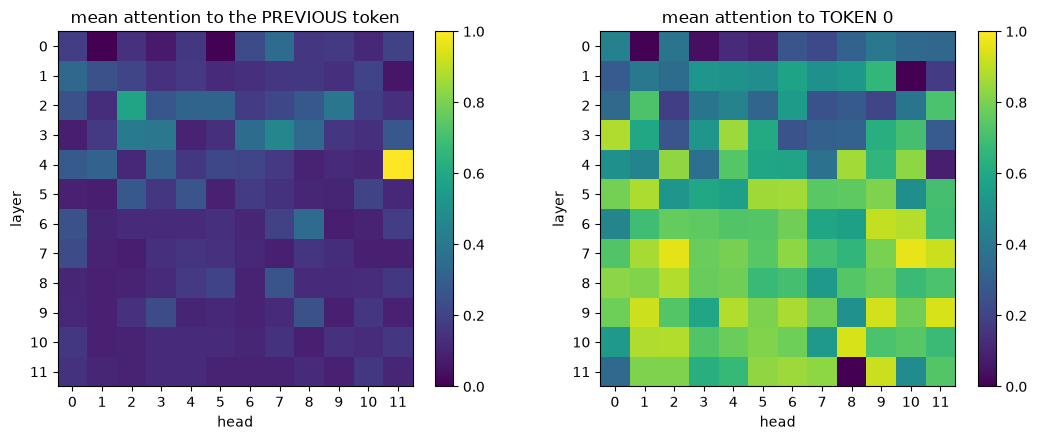

In [7]:
@torch.no_grad()
def get_attention(text: str):
    enc = tok(text, return_tensors="pt")
    out = model(**enc, output_attentions=True)
    assert out.attentions is not None and out.attentions[0] is not None, (
        "no attention weights returned: load the model with attn_implementation='eager'"
    )
    labels = [t.replace("Ġ", "_") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return labels, out.attentions  # 12 tensors, each (batch=1, heads=12, n, n)


TEXT = PROMPT
labels, atts = get_attention(TEXT)
n = len(labels)
print(f"{n} tokens: {labels}")
print(f"{len(atts)} layers; each tensor has shape {tuple(atts[0].shape)} = (batch, heads, query, key)")
print("row sums, layer 0 head 0:", [round(x, 4) for x in atts[0][0, 0].sum(dim=-1).tolist()])

# For every one of the 144 heads: how much attention goes to the PREVIOUS token, and to token 0?
prev_score = torch.zeros(cfg.n_layer, cfg.n_head)
sink_score = torch.zeros(cfg.n_layer, cfg.n_head)
for L in range(cfg.n_layer):
    a = atts[L][0]  # (heads, n, n)
    prev_score[L] = torch.stack([a[:, i, i - 1] for i in range(1, n)]).mean(dim=0)
    sink_score[L] = a[:, 1:, 0].mean(dim=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, score, title in [
    (axes[0], prev_score, "mean attention to the PREVIOUS token"),
    (axes[1], sink_score, "mean attention to TOKEN 0"),
]:
    im = ax.imshow(score.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("head")
    ax.set_ylabel("layer")
    ax.set_xticks(range(cfg.n_head))
    ax.set_yticks(range(cfg.n_layer))
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

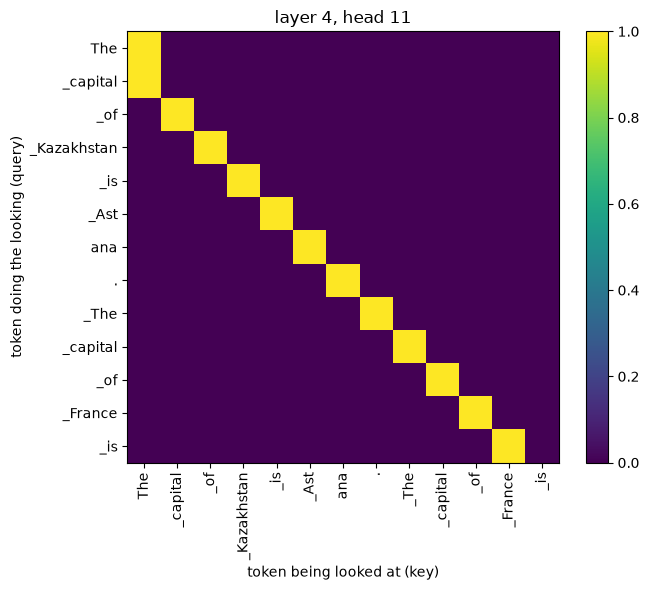

In [8]:
def attention_heatmap(text: str, layer: int, head: int) -> None:
    labels, atts = get_attention(text)
    a = atts[layer][0, head]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(a.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("token being looked at (key)")
    ax.set_ylabel("token doing the looking (query)")
    ax.set_title(f"layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


LAYER, HEAD = 4, 11  # ✏️ TODO: the (layer, head) that the LEFT grid shows as a previous-token head
attention_heatmap(TEXT, LAYER, HEAD)

**✏️ Your answers.**

1. Read the left grid above. Which (layer, head) looks most like a "previous-token" head? Put it into `LAYER, HEAD` in the cell above and re-run it. What pattern do you see in the heatmap, and why is it a diagonal just *below* the main diagonal?
2. Does every head in that layer do the same thing?

> **1.** Layer 4, head 11 (score 1.000). The heatmap is one bright line just below the main diagonal: every token puts almost all its attention on the token right before it. It is *below* the diagonal because row i looks at column i−1 (the previous position), and the main diagonal would be the token looking at itself.
>
> **2.** No. The other heads in layer 4 have previous-token scores of only 0.10–0.31, and most of them put 0.4–0.9 of their attention on token 0 instead. Head 11 is the only previous-token head there.

In [9]:
# Check yourself: the three heads with the highest previous-token score for this prompt.
for v, idx in zip(*torch.topk(prev_score.flatten(), 3)):
    L, H = divmod(idx.item(), cfg.n_head)
    print(f"layer {L}, head {H}: {v.item():.3f} of its attention goes to the previous token")

layer 4, head 11: 1.000 of its attention goes to the previous token
layer 2, head 2: 0.585 of its attention goes to the previous token
layer 3, head 7: 0.462 of its attention goes to the previous token


most extreme head on the RIGHT grid: layer 7, head 10  (mean attention to token 0 = 0.964)
mean attention to token 0, averaged over the 12 heads of each layer:
   [0.25, 0.42, 0.4, 0.52, 0.57, 0.72, 0.71, 0.81, 0.74, 0.79, 0.75, 0.66]


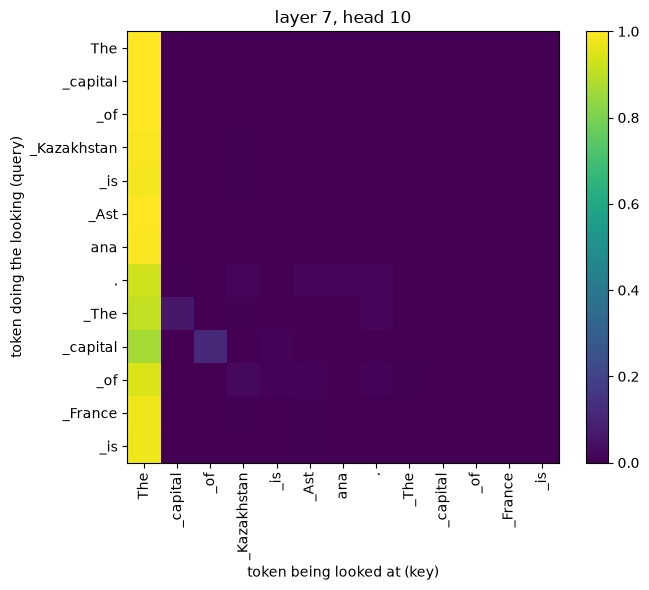

In [10]:
sink_layer, sink_head = divmod(sink_score.argmax().item(), cfg.n_head)
print(f"most extreme head on the RIGHT grid: layer {sink_layer}, head {sink_head}  "
      f"(mean attention to token 0 = {sink_score[sink_layer, sink_head]:.3f})")
print("mean attention to token 0, averaged over the 12 heads of each layer:")
print("  ", [round(x, 2) for x in sink_score.mean(dim=1).tolist()])
attention_heatmap(TEXT, sink_layer, sink_head)

### Two traps

**The bright first column.** In layers 5–10 the *average* head puts roughly 70–80% of its attention on
token 0 (measured above, for this prompt), and the most extreme head puts over 95% there. That is not
"the model is thinking about the word *The*". The usual explanation — which this lab does not test — is that a softmax
row must sum to 1, so a head with nothing useful to look at has to put its weight somewhere, and the first
token is where it goes. Either way, the bright column tells you how the mechanism is built, not what the
first word means. Which head is the most extreme one changes from text to text; the phenomenon does not.

**A weight is not an explanation.** A high attention weight says how much of a token's *value vector* is
averaged in. It does not say how much that token changed the answer. Lecture 3 cited the papers that argue
about this; the heatmap is a picture of a mechanism, not a proof of a reason.

**✏️ Your answer.** Which layers have the highest average attention to token 0? Given the trap above, would you
report "the model focuses on the first word" to a manager? What would you say instead?

> **Answer:** Layers 5–10 (highest is layer 7 with 0.81; the most extreme head is layer 7, head 10 with 0.964). I would not say "the model focuses on the first word". I would say: many heads in the middle layers park most of their attention on the first token, probably because each row must sum to 1 and there is nothing useful to look at — it is a feature of the mechanism, not evidence that the word *The* matters for the answer.

## Part 3 — the same model, in Kazakh (5 min)

Lecture 3's claim: Kazakh costs more because of the **table**, not the language. GPT-2's table has only
50,257 entries; how well it covers Russian and Kazakh is what you measure now. Three parallel sentences
(my translations — if you spot an error, say so):

**✏️ Predict first.** Which language needs the most tokens *per character*? Lecture 3 (slide 2) measured Kazakh at
1.7–4.8× the English token count and Russian at 1.2–2.9×, across six tokenizers. Will Kazakh be clearly worse than
Russian on GPT-2 as well?

> **Prediction:** Kazakh will be clearly worse than Russian, maybe 1.3× more tokens per character, because of the extra letters (ә, қ, ң, ө …).
>
> **Measured:** en 0.22, ru 1.11, kk 1.10 tokens/char. Kazakh is *not* worse per character (1.10 vs 1.11); it only has more tokens in total (34 vs 31) because the sentence is longer. Both are ~4× English. My prediction was wrong.

In [11]:
SENTENCES = {
    "en": "The capital of Kazakhstan is Astana.",
    "ru": "Столица Казахстана — Астана.",
    "kk": "Қазақстанның астанасы — Астана.",
}

print(f"{'lang':<5}{'chars':>6}{'bytes':>7}{'tokens':>8}{'tokens/char':>13}{'x English':>11}")
en_tokens = len(tok.encode(SENTENCES["en"]))
for lang, s in SENTENCES.items():
    t = len(tok.encode(s))
    print(f"{lang:<5}{len(s):>6}{len(s.encode()):>7}{t:>8}{t / len(s):>13.2f}{t / en_tokens:>11.2f}")

lang  chars  bytes  tokens  tokens/char  x English
en       36     36       8         0.22       1.00
ru       28     53      31         1.11       3.88
kk       31     59      34         1.10       4.25


In [12]:
@torch.no_grad()
def greedy_continue(prompt: str, n_tokens: int = 20) -> str:
    """Slide 14's loop, written out: pick the #1 token, append it, repeat."""
    ids = tok(prompt, return_tensors="pt")["input_ids"]
    for _ in range(n_tokens):
        next_id = model(input_ids=ids).logits[0, -1].argmax()
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)
    return tok.decode(ids[0])


for prompt in ["The capital of Kazakhstan is", "Столица Казахстана —", "Қазақстанның астанасы —"]:
    show_next_token(prompt, k=3)
    top1 = int(next_token_logits(prompt).argmax())
    print(f"  #1 token as raw text: {tok.convert_ids_to_tokens(top1)!r}")
    print("  greedy, 20 tokens:", repr(greedy_continue(prompt)))
    print()

prompt: 'The capital of Kazakhstan is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   8.98%   id    262   ' the'
   7.63%   id   1363   ' home'
   5.89%   id    257   ' a'
  top-3 hold 22.5%; the other 50,254 tokens share 77.5%
  #1 token as raw text: 'Ġthe'


  greedy, 20 tokens: "The capital of Kazakhstan is the capital of the country's former Soviet Union, and the country's president, Nursultan Nazar"

prompt: 'Столица Казахстана —'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  37.79%   id  12466   ' �'
   2.40%   id    198   '\n'
   2.34%   id    220   ' '
  top-3 hold 42.5%; the other 50,254 tokens share 57.5%
  #1 token as raw text: 'ĠÐ'


  greedy, 20 tokens: 'Столица Казахстана — Столица Казахста'

prompt: 'Қазақстанның астанасы —'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.54%   id  12466   ' �'
   4.11%   id    220   ' '
   2.39%   id    198   '\n'
  top-3 hold 29.0%; the other 50,254 tokens share 71.0%


  #1 token as raw text: 'ĠÐ'


  greedy, 20 tokens: 'Қазақстанның астанасы — проссии проссии про'



**✏️ Your answer.** One or two sentences. Look at the `tokens/char` column and at the #1 next token for the
Russian and Kazakh prompts. What does the model see, and why does it break? Is the problem the Kazakh
*language*, or something else? What would you change to fix it?

> **Answer:** For both Russian and Kazakh the model sees about one byte-token per character, and its #1 next token is ` Ð` — just the first byte of some Cyrillic letter (37.8% for Russian, 22.5% for Kazakh), so greedy generation only repeats the prompt (Russian) or produces broken text like `проссии` (Kazakh). The problem is not the Kazakh language but the table: GPT-2's tokenizer and training data are English, so Russian breaks almost the same way; the fix is a tokenizer and training data that include Cyrillic/Kazakh text (a bigger multilingual vocabulary, e.g. o200k, or a model trained on Kazakh).

## What you hand in

Download this notebook (*File → Download → .ipynb*) **after** you have run every cell and filled in every ✏️, and upload it to Canvas.

1. The four predictions (Parts 0, 1, temperature, 3), written before you ran the cell, with the measured value next to each.
2. Your one-sentence difference between temperature and top-p.
3. The (layer, head) you found for the previous-token pattern, and the (layer, head) of the most extreme "token 0" head.
4. Your Part 3 answer.

Extension tasks are in the README of this repository. They are optional.